<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_7_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 13. Ensemble Methods: Random Forests & Gradient Boosting
### Statistics & Quantitative Methods for Data Science

A single decision tree (Week 5) is easy to interpret but prone to high variance — small changes in training data can produce a very different tree. **Ensemble methods** combine many models to get something more accurate and stable than any one of them alone, using two very different statistical strategies: *averaging* and *sequential correction*.

**This notebook:**
1. Why combine models? The wisdom of crowds, statistically
2. Bagging & Random Forests (variance reduction via averaging)
3. Feature importance
4. Boosting & Gradient Boosting (bias reduction via sequential correction)
5. Bagging vs. boosting, compared
6. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)

df = titanic.dropna(subset=['age','fare','pclass','sibsp','parch','sex','survived']).copy()
df['sex_code'] = df['sex'].map({'male':0,'female':1})
features = ['pclass','sex_code','age','sibsp','parch','fare']
X, y = df[features], df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

---
# 1. Why combine models? The wisdom of crowds, statistically

Recall the **Central Limit Theorem** (Week 2): averaging many noisy, independent estimates produces a result with far less variance than any single estimate — the standard error shrinks by $1/\sqrt{n}$. Ensembling applies the exact same logic to *predictions*: if individual models' errors are somewhat independent, averaging their predictions cancels out much of the noise while keeping the signal.

In [ ]:
# A direct illustration: average many noisy single-tree predictions vs trusting one tree
single_tree_accs = []
for i in range(50):
    boot_idx = np.random.RandomState(i).choice(len(X_train), size=len(X_train), replace=True)
    tree = DecisionTreeClassifier(max_depth=5, random_state=i).fit(X_train.iloc[boot_idx], y_train.iloc[boot_idx])
    single_tree_accs.append(accuracy_score(y_test, tree.predict(X_test)))

print(f"Individual trees: mean acc={np.mean(single_tree_accs):.3f}, std={np.std(single_tree_accs):.3f}")
print(f"(Some individual trees do better, some worse -- that variance is exactly what we want to average away)")

Individual trees: mean acc=0.777, std=0.023
(Some individual trees do better, some worse -- that variance is exactly what we want to average away)


---
# 2. Bagging & Random Forests

**Bagging** (Bootstrap AGGregating) trains many copies of a model on different **bootstrap samples** (Week 3!) of the training data, then averages (regression) or majority-votes (classification) their predictions. A **Random Forest** adds one more trick: each tree also only considers a **random subset of features** at each split, decorrelating the trees further so their errors are less likely to overlap.

In [ ]:
bagging = BaggingClassifier(DecisionTreeClassifier(max_depth=5), n_estimators=50, random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42).fit(X_train, y_train)

acc_bagging = accuracy_score(y_test, bagging.predict(X_test))
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_single_tree = accuracy_score(y_test, DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train).predict(X_test))

print(f"Single tree accuracy:    {acc_single_tree:.3f}")
print(f"Bagged trees accuracy:   {acc_bagging:.3f}")
print(f"Random Forest accuracy:  {acc_rf:.3f}")

Single tree accuracy:    0.793
Bagged trees accuracy:   0.788
Random Forest accuracy:  0.788


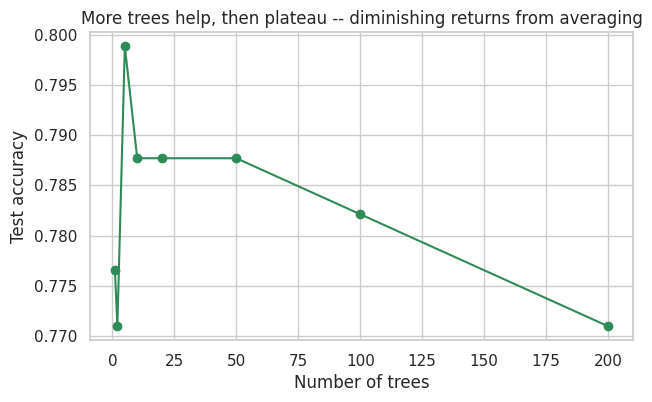

In [ ]:
# How many trees do we need? Diminishing returns, same 1/sqrt(n) shape we've seen before
n_estimators_range = [1, 2, 5, 10, 20, 50, 100, 200]
rf_accs = []
for n in n_estimators_range:
    rf_n = RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42).fit(X_train, y_train)
    rf_accs.append(accuracy_score(y_test, rf_n.predict(X_test)))

plt.plot(n_estimators_range, rf_accs, marker='o', color='seagreen')
plt.xlabel('Number of trees'); plt.ylabel('Test accuracy')
plt.title('More trees help, then plateau -- diminishing returns from averaging')
plt.show()

In [ ]:
# Cross-validated comparison (Week 5): mean +/- std across folds, not a single lucky split
for name, model in [('Single Tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
                     ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))]:
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name:15s} CV accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")

Single Tree     CV accuracy: 0.797 +/- 0.046


Random Forest   CV accuracy: 0.797 +/- 0.044


---
# 3. Feature importance

Random Forests give a natural, model-based measure of **feature importance**: how much each feature reduces impurity (Week 5's entropy) on average, across all trees and all splits. This is a very different (and often more powerful) approach to "which features matter" than the filter methods from Week 5, Class 1, because it accounts for interactions between features automatically.

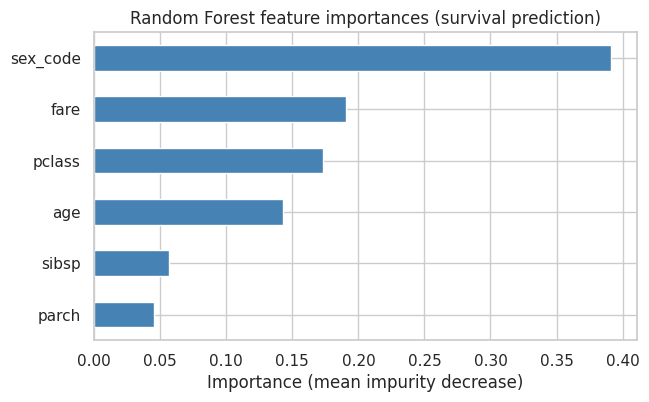

In [ ]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest feature importances (survival prediction)')
plt.xlabel('Importance (mean impurity decrease)')
plt.show()

---
# 4. Boosting & Gradient Boosting

Bagging trains trees **independently and in parallel**, then averages (reduces *variance*). **Boosting** does the opposite: it trains trees **sequentially**, where each new tree focuses specifically on correcting the mistakes of the ensemble so far (reduces *bias*, by design, though it can overfit — increase variance — if allowed to run too long).

**Gradient Boosting** formalizes "correcting mistakes" as: each new tree is fit to the **residual errors** of the current ensemble — literally predicting what's still wrong.

Gradient Boosting accuracy: 0.793


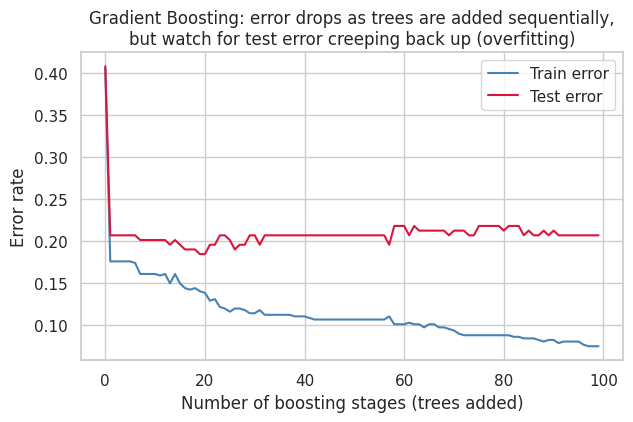

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42).fit(X_train, y_train)
acc_gb = accuracy_score(y_test, gb.predict(X_test))
print(f"Gradient Boosting accuracy: {acc_gb:.3f}")

# Watch training/test error evolve as MORE trees get added sequentially -- unique to boosting
train_errors, test_errors = [], []
for i, y_pred_train in enumerate(gb.staged_predict(X_train)):
    train_errors.append(1 - accuracy_score(y_train, y_pred_train))
for i, y_pred_test in enumerate(gb.staged_predict(X_test)):
    test_errors.append(1 - accuracy_score(y_test, y_pred_test))

plt.plot(train_errors, label='Train error', color='steelblue')
plt.plot(test_errors, label='Test error', color='crimson')
plt.xlabel('Number of boosting stages (trees added)'); plt.ylabel('Error rate'); plt.legend()
plt.title('Gradient Boosting: error drops as trees are added sequentially,\nbut watch for test error creeping back up (overfitting)')
plt.show()

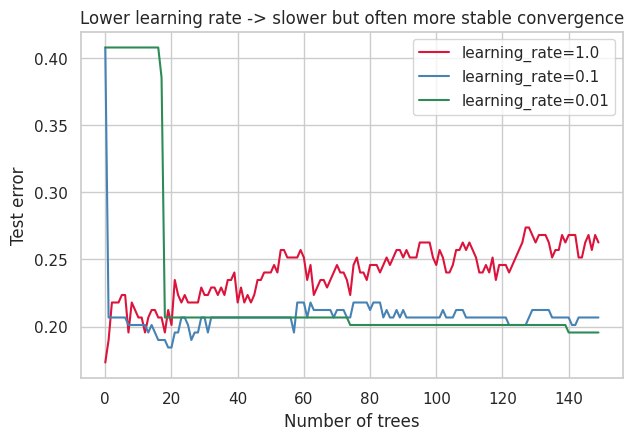

In [ ]:
# learning_rate controls how much each new tree corrects -- smaller = more conservative, needs more trees
fig, ax = plt.subplots(figsize=(7,4.5))
for lr, color in [(1.0, 'crimson'), (0.1, 'steelblue'), (0.01, 'seagreen')]:
    gb_lr = GradientBoostingClassifier(n_estimators=150, learning_rate=lr, max_depth=3, random_state=42)
    gb_lr.fit(X_train, y_train)
    test_err = [1 - accuracy_score(y_test, pred) for pred in gb_lr.staged_predict(X_test)]
    ax.plot(test_err, label=f'learning_rate={lr}', color=color)
ax.set_xlabel('Number of trees'); ax.set_ylabel('Test error'); ax.legend()
ax.set_title('Lower learning rate -> slower but often more stable convergence')
plt.show()

---
# 5. Bagging vs. boosting, compared

| | Bagging / Random Forest | Boosting / Gradient Boosting |
|---|---|---|
| Trees trained | In parallel, independently | Sequentially, each correcting the last |
| Primarily reduces | Variance (via CLT-style averaging) | Bias (via targeted error correction) |
| Overfitting risk | Low — more trees rarely hurts much | Higher — too many stages can overfit; needs tuning |
| Typical strength | Robust, hard to overfit, easy to parallelize | Often higher raw accuracy, more sensitive to tuning |

                     Model  Test Accuracy
0     Single Decision Tree       0.793296
1  Random Forest (bagging)       0.787709
2        Gradient Boosting       0.793296


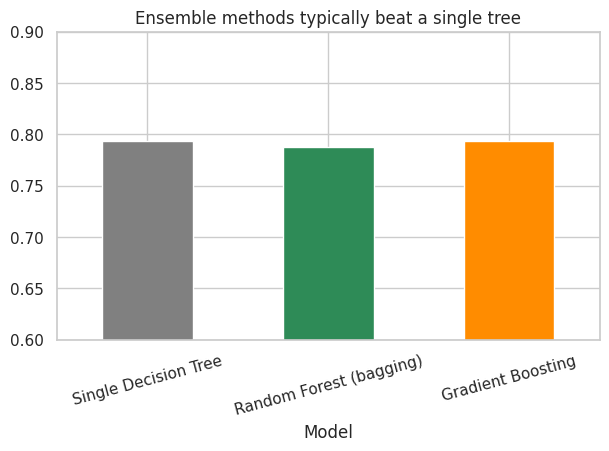

In [ ]:
results = pd.DataFrame({
    'Model': ['Single Decision Tree', 'Random Forest (bagging)', 'Gradient Boosting'],
    'Test Accuracy': [acc_single_tree, acc_rf, acc_gb]
})
print(results)
results.plot(x='Model', y='Test Accuracy', kind='bar', legend=False, color=['gray','seagreen','darkorange'])
plt.ylim(0.6, 0.9); plt.xticks(rotation=15)
plt.title('Ensemble methods typically beat a single tree')
plt.show()

---
# 6. Exercises

1. Re-run the "how many trees" sweep (Section 2) for `BaggingClassifier` instead of `RandomForestClassifier`. Does it plateau at a similar point?
2. Compute feature importances for a Gradient Boosting model instead of the Random Forest (Section 3). Are the top features the same?
3. Increase `n_estimators` for `GradientBoostingClassifier` to 500 while keeping `learning_rate=1.0`. Does test error eventually start rising (overfitting)? Compare to `learning_rate=0.05` with the same 500 estimators.
4. Run 5-fold cross-validation (Week 5 style: mean +/- std) comparing Random Forest and Gradient Boosting. Which has the higher mean accuracy? Which has the smaller std (more consistent across folds)?
5. **Challenge**: Look up `AdaBoostClassifier` (an earlier, simpler boosting algorithm that reweights misclassified *samples* rather than fitting to residuals). Compare its performance and its `staged_predict` error curve to `GradientBoostingClassifier`'s.
